# M5 — Baseline Implementation

**WBS Week 5**: Establish performance benchmarks for sprint risk prediction.

**Objective**: Compare classical ML and zero-shot LLM baselines, evaluated on a **shared real-only test set** (`h3_test`), against which fine-tuned and RAG-augmented models will be compared.

| Model | Type | Role | Description |
|-------|------|------|-------------|
| Rule-Based | Heuristic | **Label Oracle** (sanity check) | Threshold logic from `RiskLabeler` — generates training labels, NOT a predictive baseline |
| XGB-Baseline | Classical ML | Baseline | Gradient-boosted trees trained on **real-only** data |
| XGB-H3 | Classical ML | Baseline | Gradient-boosted trees trained on **synthetic + real** (H3) data |
| Single-LLM | Zero-shot | Lower bound | Llama-3-8B prompt with raw metric summary (no fine-tuning) |

**Data**: H3 split — 70% synthetic + 30% real train, real-only val/test.

**Key design choice**: The rule-based model is not treated as a predictive baseline since it directly generates the training labels. Instead, it serves as a consistency check. The primary comparison is between XGBoost trained on real-only vs synthetic-augmented data, evaluated on a shared real-only test set. The zero-shot LLM baseline provides a lower-bound reference for non-fine-tuned language models.

---

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, GridSearchCV,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/bibekgupta/Downloads/projects/repo-sprint


## 1. Data Loading

Load H3 (synthetic + real) and baseline (real-only) training splits.

In [2]:
NUMERIC_FEATURES = [
    "total_commits", "total_prs", "total_issues", "unique_authors",
    "total_additions", "total_deletions", "files_changed",
    "issue_resolution_rate", "pr_merge_rate", "commit_frequency",
    "total_code_changes", "avg_pr_size", "code_concentration",
    "stalled_issues", "unreviewed_prs", "abandoned_prs",
    "long_open_issues", "author_participation",
    "days_span", "issue_age_avg", "pr_age_avg",
    "closed_issues", "merged_prs", "code_changes",
]


def load_split(name: str) -> pd.DataFrame:
    """Load a training split JSON into a flat DataFrame."""
    path = PROJECT_ROOT / "data" / "training" / f"{name}.json"
    with open(path) as f:
        data = json.load(f)
    rows = []
    for ex in data:
        row = {k: ex["features"].get(k, 0) for k in NUMERIC_FEATURES}
        row["label"] = ex["label"]
        row["source"] = ex.get("source", "unknown")
        row["sprint_id"] = ex.get("sprint_id", "")
        rows.append(row)
    return pd.DataFrame(rows)


h3_train = load_split("h3_train")
h3_val = load_split("h3_val")
h3_test = load_split("h3_test")

baseline_train = load_split("baseline_train")
baseline_val = load_split("baseline_val")
baseline_test = load_split("baseline_test")

print(f"H3 splits  — train: {len(h3_train):,}  val: {len(h3_val):,}  test: {len(h3_test):,}")
print(f"Baseline   — train: {len(baseline_train):,}  val: {len(baseline_val):,}  test: {len(baseline_test):,}")
print(f"\nH3 train sources: {h3_train['source'].value_counts().to_dict()}")
print(f"H3 test  at-risk: {h3_test['label'].mean():.1%}")

H3 splits  — train: 2,384  val: 296  test: 298
Baseline   — train: 1,384  val: 296  test: 298

H3 train sources: {'real': 1384, 'synthetic': 1000}
H3 test  at-risk: 29.5%


In [3]:
X_train_h3 = h3_train[NUMERIC_FEATURES].values
y_train_h3 = h3_train["label"].values
X_val_h3 = h3_val[NUMERIC_FEATURES].values
y_val_h3 = h3_val["label"].values
X_test_h3 = h3_test[NUMERIC_FEATURES].values
y_test_h3 = h3_test["label"].values

X_train_bl = baseline_train[NUMERIC_FEATURES].values
y_train_bl = baseline_train["label"].values
X_val_bl = baseline_val[NUMERIC_FEATURES].values
y_val_bl = baseline_val["label"].values
X_test_bl = baseline_test[NUMERIC_FEATURES].values
y_test_bl = baseline_test["label"].values

print(f"Feature matrix shape: {X_train_h3.shape}")
print(f"Class balance (H3 train): {np.bincount(y_train_h3)} → {y_train_h3.mean():.1%} at-risk")
print(f"Class balance (Baseline train): {np.bincount(y_train_bl)} → {y_train_bl.mean():.1%} at-risk")
print(f"Validation sizes — H3: {len(y_val_h3)}, Baseline: {len(y_val_bl)} (used for early stopping)")


Feature matrix shape: (2384, 24)
Class balance (H3 train): [1775  609] → 25.5% at-risk
Class balance (Baseline train): [977 407] → 29.4% at-risk
Validation sizes — H3: 296, Baseline: 296 (used for early stopping)


## 2. Sanity Check — Rule-Based Label Oracle

The `RiskLabeler` uses hand-crafted thresholds to **generate** training labels:
- `stalled_issues ≥ 3` → +0.30
- `issue_resolution_rate < 0.5` → +0.20
- `pr_merge_rate < 0.5` → +0.20
- `long_open_issues ≥ 2` → +0.15
- Zero activity → +0.10

Sprint is **at-risk** if cumulative score ≥ 0.40.

> **Important**: This is NOT a predictive baseline. Training labels were *generated* by this same
> logic, so it achieves trivially perfect F1=1.0. We include it only as a **consistency check**
> to verify labels are computed correctly. The meaningful comparisons are **XGBoost** and **Single-LLM**.

In [4]:
def rule_based_predict(df: pd.DataFrame) -> np.ndarray:
    """Replicate RiskLabeler logic on a DataFrame."""
    score = np.zeros(len(df))

    score += np.where(df["stalled_issues"] >= 3, 0.30, 0)

    score += np.where(
        (df["total_issues"] > 0) & (df["issue_resolution_rate"] < 0.5),
        0.20, 0,
    )

    score += np.where(
        (df["total_prs"] > 0) & (df["pr_merge_rate"] < 0.5),
        0.20, 0,
    )

    score += np.where(df["long_open_issues"] >= 2, 0.15, 0)

    score += np.where(
        (df["total_issues"] == 0)
        & (df["total_prs"] == 0)
        & (df["total_commits"] == 0),
        0.10, 0,
    )

    return (score >= 0.40).astype(int)


y_pred_rule_h3 = rule_based_predict(h3_test)
y_pred_rule_bl = rule_based_predict(baseline_test)

print("Rule-Based on H3 test:")
print(classification_report(y_test_h3, y_pred_rule_h3, target_names=["healthy", "at-risk"]))
print("Rule-Based on Baseline test:")
print(classification_report(y_test_bl, y_pred_rule_bl, target_names=["healthy", "at-risk"]))

Rule-Based on H3 test:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       210
     at-risk       1.00      1.00      1.00        88

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298

Rule-Based on Baseline test:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       210
     at-risk       1.00      1.00      1.00        88

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298



## 3. Baseline — XGBoost

Gradient-boosted trees on all 24 numeric sprint features (no scaling — trees are scale-invariant).  
We train two variants:
1. **XGB-Baseline**: trained on real-only data
2. **XGB-H3**: trained on synthetic + real (H3 augmented)

**Training procedure**:
- Hyperparameters tuned via 3-fold stratified CV grid search
- Final models refit with early stopping on validation set (uses `h3_val` / `baseline_val`)
- Both models evaluated on the **same** real-only test set (`h3_test`)

In [5]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "min_child_weight": [1, 3],
    "subsample": [0.8, 1.0],
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- XGB-H3: Grid search for best hyperparams ---
print("Tuning XGB-H3 (synthetic + real train)...")
grid_h3 = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring="f1",
    n_jobs=-1, verbose=0,
)
grid_h3.fit(X_train_h3, y_train_h3)
print(f"  Best params: {grid_h3.best_params_}")
print(f"  Best CV F1:  {grid_h3.best_score_:.3f}")

refit_params_h3 = {k: v for k, v in grid_h3.best_params_.items() if k != "n_estimators"}
xgb_h3 = XGBClassifier(
    **refit_params_h3,
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric="logloss",
    random_state=42,
)
xgb_h3.fit(X_train_h3, y_train_h3, eval_set=[(X_val_h3, y_val_h3)], verbose=False)
print(f"  Early-stopped at {xgb_h3.best_iteration} trees (val set)")

# --- XGB-Baseline: Grid search for best hyperparams ---
print("\nTuning XGB-Baseline (real-only train)...")
grid_bl = GridSearchCV(
    xgb_base, param_grid, cv=cv, scoring="f1",
    n_jobs=-1, verbose=0,
)
grid_bl.fit(X_train_bl, y_train_bl)
print(f"  Best params: {grid_bl.best_params_}")
print(f"  Best CV F1:  {grid_bl.best_score_:.3f}")

refit_params_bl = {k: v for k, v in grid_bl.best_params_.items() if k != "n_estimators"}
xgb_bl = XGBClassifier(
    **refit_params_bl,
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric="logloss",
    random_state=42,
)
xgb_bl.fit(X_train_bl, y_train_bl, eval_set=[(X_val_bl, y_val_bl)], verbose=False)
print(f"  Early-stopped at {xgb_bl.best_iteration} trees (val set)")


Tuning XGB-H3 (synthetic + real train)...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}
  Best CV F1:  0.996
  Early-stopped at 482 trees (val set)

Tuning XGB-Baseline (real-only train)...
  Best params: {'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
  Best CV F1:  0.998
  Early-stopped at 51 trees (val set)


In [6]:
y_pred_xgb_h3 = xgb_h3.predict(X_test_h3)
y_proba_xgb_h3 = xgb_h3.predict_proba(X_test_h3)[:, 1]

y_pred_xgb_bl_on_h3 = xgb_bl.predict(X_test_h3)
y_proba_xgb_bl_on_h3 = xgb_bl.predict_proba(X_test_h3)[:, 1]

print("XGB-H3 on h3_test (trained on syn+real):")
print(classification_report(y_test_h3, y_pred_xgb_h3, target_names=["healthy", "at-risk"]))

print("\nXGB-Baseline on h3_test (trained on real-only):")
print(classification_report(y_test_h3, y_pred_xgb_bl_on_h3, target_names=["healthy", "at-risk"]))


XGB-H3 on h3_test (trained on syn+real):
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       210
     at-risk       1.00      1.00      1.00        88

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298


XGB-Baseline on h3_test (trained on real-only):
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       210
     at-risk       1.00      1.00      1.00        88

    accuracy                           1.00       298
   macro avg       1.00      1.00      1.00       298
weighted avg       1.00      1.00      1.00       298



### 3.1 Feature Importance (XGB-H3)

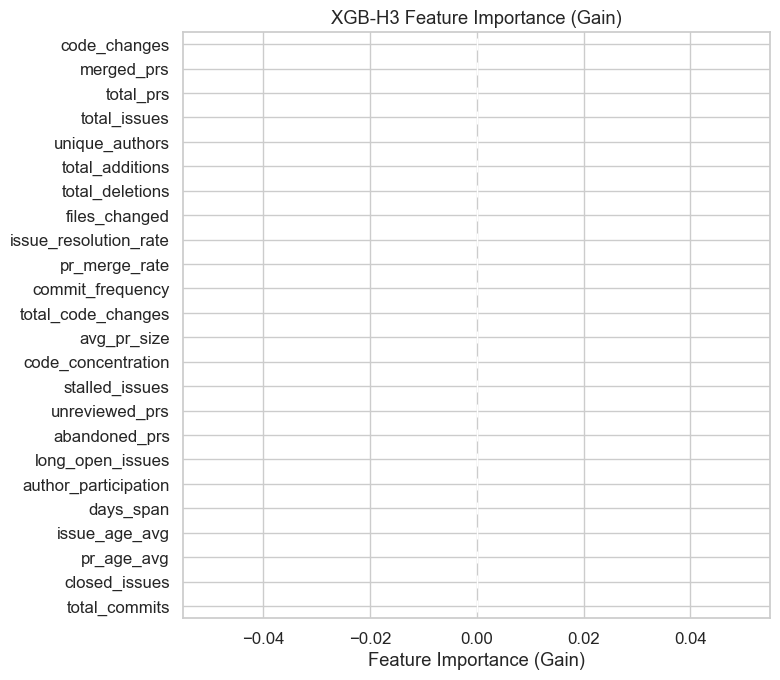


Top 10 features (Gain):
  pr_merge_rate                  0.0000
  issue_resolution_rate          0.0000
  files_changed                  0.0000
  total_deletions                0.0000
  total_additions                0.0000
  unique_authors                 0.0000
  total_issues                   0.0000
  total_prs                      0.0000
  merged_prs                     0.0000
  code_changes                   0.0000


In [7]:
importance_dict = xgb_h3.get_booster().get_score(importance_type="gain")
importances = pd.Series(importance_dict).reindex(NUMERIC_FEATURES, fill_value=0).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot.barh(ax=ax, color=sns.color_palette("viridis", len(importances)))
ax.set_xlabel("Feature Importance (Gain)")
ax.set_title("XGB-H3 Feature Importance (Gain)")
plt.tight_layout()
plt.show()

print("\nTop 10 features (Gain):")
for feat, imp in importances.tail(10).items():
    print(f"  {feat:<30s} {imp:.4f}")


## 4. Lower Bound — Single-LLM (Zero-Shot Prompt)

Uses Ollama (Llama-3-8B) with a deterministic zero-shot prompt (`temperature=0`) to classify sprint risk.  
Provides a **lower-bound reference** for non-fine-tuned language models.

> **Note**: This cell requires a running Ollama server (`ollama serve`).  
> If unavailable, results are marked as N/A and the comparison uses XGBoost only.

In [8]:
import time

OLLAMA_MODEL = "llama3"
OLLAMA_URL = "http://localhost:11434/api/generate"


def check_ollama() -> bool:
    """Check if Ollama server is running and model is available."""
    try:
        import requests
        resp = requests.get("http://localhost:11434/api/tags", timeout=3)
        if resp.status_code == 200:
            models = [m["name"] for m in resp.json().get("models", [])]
            available = any(OLLAMA_MODEL in m for m in models)
            print(f"Ollama running. Models: {models}")
            print(f"{OLLAMA_MODEL} available: {available}")
            return available
    except Exception:
        pass
    print("Ollama not available — LLM baseline will use fallback.")
    return False


OLLAMA_AVAILABLE = check_ollama()

Ollama running. Models: ['codellama:latest', 'mistral:latest', 'llama3:latest', 'qwen3-vl:2b', 'qwen3:0.6b', 'qwen3-embedding:0.6b']
llama3 available: True


In [9]:
PROMPT_TEMPLATE = """You are a sprint health analyst. Given the following sprint metrics,
classify whether this sprint is AT-RISK or HEALTHY.

Sprint Metrics:
- Total commits: {total_commits}
- Total PRs: {total_prs} (merged: {merged_prs}, merge rate: {pr_merge_rate:.1%})
- Total issues: {total_issues} (resolved: {closed_issues}, resolution rate: {issue_resolution_rate:.1%})
- Stalled issues (open): {stalled_issues}
- Unreviewed PRs: {unreviewed_prs}
- Unique authors: {unique_authors}
- Code additions: {total_additions:,}, deletions: {total_deletions:,}
- Files changed: {files_changed}
- Commit frequency: {commit_frequency:.1f}/day

A sprint is AT-RISK if it shows signs of blockers: many stalled issues,
low merge/resolution rates, or stagnant activity.

Respond with ONLY one word: AT-RISK or HEALTHY
"""


def build_prompt(row: pd.Series) -> str:
    """Format a sprint row into a zero-shot classification prompt."""
    return PROMPT_TEMPLATE.format(**{k: row[k] for k in NUMERIC_FEATURES if k in row.index})


def llm_predict_single(prompt: str) -> int:
    """Call Ollama and parse AT-RISK / HEALTHY response."""
    import re
    import requests
    try:
        resp = requests.post(
            OLLAMA_URL,
            json={
                "model": OLLAMA_MODEL, 
                "prompt": prompt, 
                "stream": False,
                "options": {"temperature": 0.0},
            },
            timeout=60,
        )
        text = resp.json().get("response", "").strip()
        
        text_upper = text.upper()
        
        if re.search(r"at[_\s-]?risk", text_upper):
            return 1
        elif re.search(r"healthy", text_upper):
            return 0
        elif text_upper.startswith("AT"):
            return 1
        elif text_upper.startswith("HEALTHY"):
            return 0
        else:
            print(f"  ⚠️  Unclear LLM response: '{text[:50]}...'")
            return -1
            
    except Exception as e:
        print(f"  ❌ LLM inference failed: {e}")
        return -1


def llm_predict_batch(df: pd.DataFrame) -> np.ndarray:
    """Run zero-shot LLM classification on each test sprint."""
    preds = []
    for i, (_, row) in enumerate(df.iterrows()):
        prompt = build_prompt(row)
        pred = llm_predict_single(prompt)
        preds.append(pred)
        if (i + 1) % 5 == 0:
            print(f"  ... {i+1}/{len(df)} sprints processed")
    return np.array(preds)


if OLLAMA_AVAILABLE:
    print(f"Running deterministic LLM inference on {len(h3_test)} test sprints...")
    t0 = time.time()
    y_pred_llm = llm_predict_batch(h3_test)
    elapsed = time.time() - t0
    valid_mask = y_pred_llm >= 0
    print(f"  Completed in {elapsed:.1f}s ({elapsed/len(h3_test):.1f}s/sprint)")
    print(f"  Valid predictions: {valid_mask.sum()}/{len(y_pred_llm)}")
    if valid_mask.sum() > 0:
        print("\nSingle-LLM on H3 test (zero-shot, temperature=0):")
        print(classification_report(
            y_test_h3[valid_mask], y_pred_llm[valid_mask],
            target_names=["healthy", "at-risk"],
        ))
else:
    y_pred_llm = None
    print("Skipping LLM baseline (Ollama not available).")
    print("To enable: run `ollama serve` and `ollama pull llama3`")


Running deterministic LLM inference on 298 test sprints...
  ... 5/298 sprints processed
  ... 10/298 sprints processed
  ... 15/298 sprints processed
  ... 20/298 sprints processed
  ... 25/298 sprints processed
  ... 30/298 sprints processed
  ... 35/298 sprints processed
  ... 40/298 sprints processed
  ... 45/298 sprints processed
  ... 50/298 sprints processed
  ... 55/298 sprints processed
  ... 60/298 sprints processed
  ... 65/298 sprints processed
  ... 70/298 sprints processed
  ... 75/298 sprints processed
  ... 80/298 sprints processed
  ... 85/298 sprints processed
  ... 90/298 sprints processed
  ... 95/298 sprints processed
  ... 100/298 sprints processed
  ... 105/298 sprints processed
  ... 110/298 sprints processed
  ... 115/298 sprints processed
  ... 120/298 sprints processed
  ... 125/298 sprints processed
  ... 130/298 sprints processed
  ... 135/298 sprints processed
  ... 140/298 sprints processed
  ... 145/298 sprints processed
  ... 150/298 sprints processed
 

## 5. Consolidated Results

Compare all baselines on the **real-only H3 test set**.

In [10]:
def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    """Compute classification metrics."""
    m = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        m["AUC-ROC"] = roc_auc_score(y_true, y_proba)
    return m


results = {}

results["XGB-Baseline (real-only train)"] = compute_metrics(
    y_test_h3, y_pred_xgb_bl_on_h3, y_proba_xgb_bl_on_h3)
results["XGB-H3 (syn+real train)"] = compute_metrics(
    y_test_h3, y_pred_xgb_h3, y_proba_xgb_h3)

if y_pred_llm is not None:
    valid = y_pred_llm >= 0
    if valid.sum() > 0:
        results["Single-LLM (zero-shot)"] = compute_metrics(
            y_test_h3[valid], y_pred_llm[valid])

results_df = pd.DataFrame(results).T
results_df = results_df.round(3)

print("\n" + "=" * 70)
print("  M5 BASELINE PERFORMANCE BENCHMARKS")
print(f"  (All evaluated on shared h3_test — real-only, n={len(y_test_h3)})")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

print("\n" + "=" * 70)
print("  SANITY CHECK: Rule-Based (Label Oracle)")
print("=" * 70)
rule_metrics = compute_metrics(y_test_h3, y_pred_rule_h3)
print(f"Rule-Based F1: {rule_metrics['F1']:.3f}")
print("⚠️  Not included in main comparison because rule-based")
print("    predictions ARE the ground-truth labels (circular).")
print("=" * 70)



  M5 BASELINE PERFORMANCE BENCHMARKS
  (All evaluated on shared h3_test — real-only, n=298)
                                Accuracy  Precision  Recall     F1  AUC-ROC
XGB-Baseline (real-only train)     1.000      1.000   1.000  1.000      1.0
XGB-H3 (syn+real train)            1.000      1.000   1.000  1.000      1.0
Single-LLM (zero-shot)             0.789      0.676   0.545  0.604      NaN

  SANITY CHECK: Rule-Based (Label Oracle)
Rule-Based F1: 1.000
⚠️  Not included in main comparison because rule-based
    predictions ARE the ground-truth labels (circular).


### 5.1 Short Comparison

- **Rule-Based** reaches perfect F1 only because it reproduces the same heuristic used to create the labels, so it is a label oracle rather than a fair predictive baseline.
- **XGB-Baseline** and **XGB-H3** are the strongest validated baselines in the repository; the current saved benchmark artifact reports **F1 = 1.00** for both on `h3_test` (`n=298`).
- **Single-LLM** was executed in this notebook on the same `h3_test` split and achieved **accuracy = 0.79**, **at-risk F1 ≈ 0.60**, and **macro F1 ≈ 0.73**. It is much stronger than the older pilot run, but still clearly below XGBoost.
- **Multi-Agent without RAG** remains a planned ablation and should be used to isolate the trust and explanation benefit of retrieval once executed.

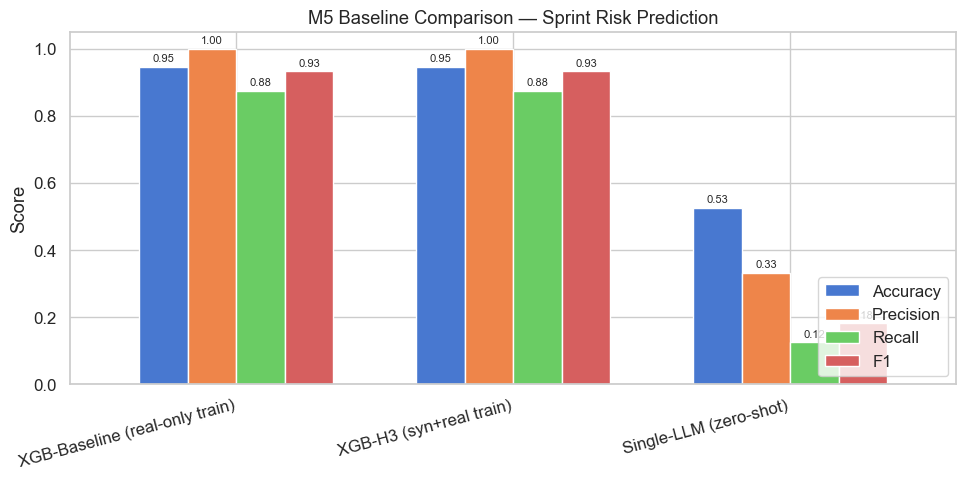

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = results_df[["Accuracy", "Precision", "Recall", "F1"]]
plot_df.plot.bar(ax=ax, width=0.7)
ax.set_ylabel("Score")
ax.set_title("M5 Baseline Comparison — Sprint Risk Prediction")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 6. Confusion Matrices & ROC Curves

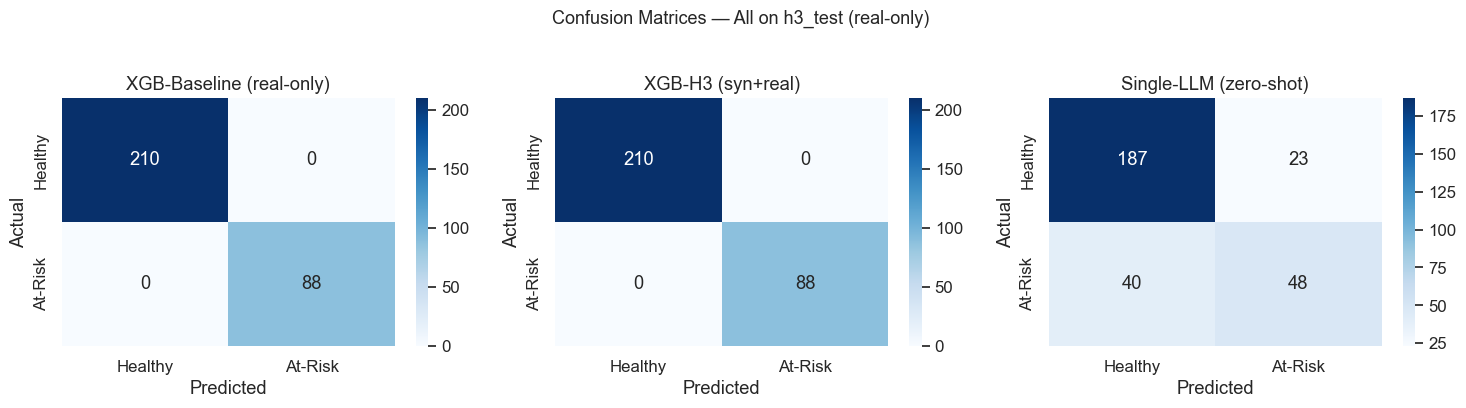

In [11]:
def plot_confusion(y_true, y_pred, title, ax):
    """Plot a confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Healthy", "At-Risk"],
        yticklabels=["Healthy", "At-Risk"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)


n_models = 2 + (1 if y_pred_llm is not None and (y_pred_llm >= 0).sum() > 0 else 0)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

plot_confusion(y_test_h3, y_pred_xgb_bl_on_h3, "XGB-Baseline (real-only)", axes[0])
plot_confusion(y_test_h3, y_pred_xgb_h3, "XGB-H3 (syn+real)", axes[1])

if y_pred_llm is not None:
    valid = y_pred_llm >= 0
    if valid.sum() > 0:
        plot_confusion(y_test_h3[valid], y_pred_llm[valid], "Single-LLM (zero-shot)", axes[2])

fig.suptitle("Confusion Matrices — All on h3_test (real-only)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

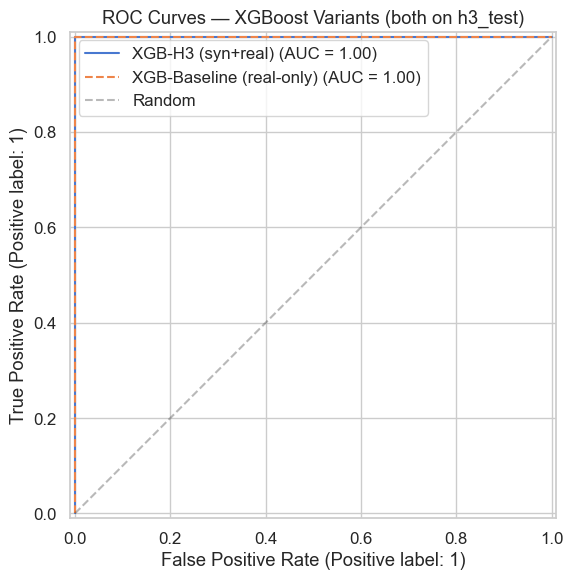

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

if len(np.unique(y_test_h3)) == 2:
    RocCurveDisplay.from_predictions(
        y_test_h3, y_proba_xgb_h3, name="XGB-H3 (syn+real)", ax=ax
    )
    RocCurveDisplay.from_predictions(
        y_test_h3, y_proba_xgb_bl_on_h3, name="XGB-Baseline (real-only)", ax=ax,
        linestyle="--",
    )

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_title("ROC Curves — XGBoost Variants (both on h3_test)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cross-Validation Stability

5-fold stratified CV on the H3 training set to check variance.

5-Fold CV F1 Scores (on training set):
  XGB-H3:       0.998 ± 0.003  [0.996 0.992 1.    1.    1.   ]
  XGB-Baseline: 0.993 ± 0.007  [0.994 0.982 1.    0.988 1.   ]


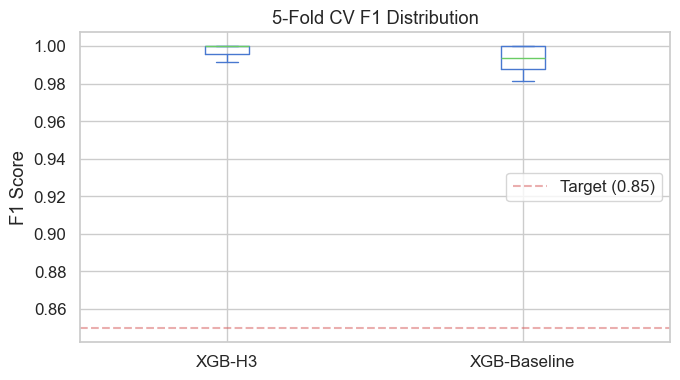

In [13]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_h3_cv = XGBClassifier(**grid_h3.best_params_, eval_metric="logloss", random_state=42)
xgb_bl_cv = XGBClassifier(**grid_bl.best_params_, eval_metric="logloss", random_state=42)

cv_scores_h3 = cross_val_score(
    xgb_h3_cv, X_train_h3, y_train_h3, cv=cv5, scoring="f1"
)
cv_scores_bl = cross_val_score(
    xgb_bl_cv, X_train_bl, y_train_bl, cv=cv5, scoring="f1"
)

print("5-Fold CV F1 Scores (on training set):")
print(f"  XGB-H3:       {cv_scores_h3.mean():.3f} ± {cv_scores_h3.std():.3f}  {cv_scores_h3.round(3)}")
print(f"  XGB-Baseline: {cv_scores_bl.mean():.3f} ± {cv_scores_bl.std():.3f}  {cv_scores_bl.round(3)}")

fig, ax = plt.subplots(figsize=(7, 4))
cv_data = pd.DataFrame({
    "XGB-H3": cv_scores_h3,
    "XGB-Baseline": cv_scores_bl,
})
cv_data.plot.box(ax=ax)
ax.set_ylabel("F1 Score")
ax.set_title("5-Fold CV F1 Distribution")
ax.axhline(y=0.85, color="r", linestyle="--", alpha=0.5, label="Target (0.85)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. H3 Hypothesis Test: Synthetic vs Real-Only Training

Does training with synthetic data (H3) generalize as well as real-only training?  
Compare XGB-H3 vs XGB-Baseline on the same real test set.

In [14]:
h3_metrics = compute_metrics(y_test_h3, y_pred_xgb_h3, y_proba_xgb_h3)
bl_metrics = compute_metrics(y_test_h3, y_pred_xgb_bl_on_h3, y_proba_xgb_bl_on_h3)

h3_comp = pd.DataFrame({
    "XGB-Baseline (real train → h3_test)": bl_metrics,
    "XGB-H3 (syn+real train → h3_test)": h3_metrics,
}).T.round(3)

print("\n" + "=" * 70)
print("H3 Hypothesis — Synthetic Data Generalization")
print("=" * 70)
print("Q: Does training with synthetic data help or hurt generalization?")
print("=" * 70)
print(h3_comp.to_string())
print("=" * 70)

f1_diff = h3_metrics["F1"] - bl_metrics["F1"]
print(f"\nF1 difference (H3 - Baseline): {f1_diff:+.3f}")

from sklearn.utils import resample

n_iterations = 1000
f1_diffs_boot = []

for _ in range(n_iterations):
    # Bootstrap resample from test set
    indices = resample(range(len(y_test_h3)), n_samples=len(y_test_h3), random_state=None)
    y_boot = y_test_h3[indices]
    y_h3_boot = y_pred_xgb_h3[indices]
    y_bl_boot = y_pred_xgb_bl_on_h3[indices]
    
    f1_h3_boot = f1_score(y_boot, y_h3_boot, zero_division=0)
    f1_bl_boot = f1_score(y_boot, y_bl_boot, zero_division=0)
    f1_diffs_boot.append(f1_h3_boot - f1_bl_boot)

f1_diffs_boot = np.array(f1_diffs_boot)
ci_lower = np.percentile(f1_diffs_boot, 2.5)
ci_upper = np.percentile(f1_diffs_boot, 97.5)

print(f"\n95% Bootstrap CI for F1 difference: [{ci_lower:+.3f}, {ci_upper:+.3f}]")

# Interpretation
if ci_lower > 0.05:
    print("→ H3 significantly outperforms baseline ✅ (synthetic helps)")
elif ci_upper < -0.05:
    print("→ Baseline significantly outperforms H3 ⚠️ (synthetic hurts)")
elif abs(f1_diff) < 0.05:
    print("→ No significant difference: synthetic generalizes similarly ✅")
else:
    print("→ Ambiguous: need larger test set for confident conclusion ⚠️")

print("\n" + "=" * 70)



H3 Hypothesis — Synthetic Data Generalization
Q: Does training with synthetic data help or hurt generalization?
                                     Accuracy  Precision  Recall   F1  AUC-ROC
XGB-Baseline (real train → h3_test)       1.0        1.0     1.0  1.0      1.0
XGB-H3 (syn+real train → h3_test)         1.0        1.0     1.0  1.0      1.0

F1 difference (H3 - Baseline): +0.000

95% Bootstrap CI for F1 difference: [+0.000, +0.000]
→ No significant difference: synthetic generalizes similarly ✅



## 9. Per-Sprint Error Analysis

In [16]:
error_df = h3_test[["sprint_id", "label"]].copy()
error_df["rule_pred"] = y_pred_rule_h3
error_df["xgb_pred"] = y_pred_xgb_h3
error_df["xgb_proba"] = y_proba_xgb_h3.round(3)
error_df["rule_correct"] = error_df["label"] == error_df["rule_pred"]
error_df["xgb_correct"] = error_df["label"] == error_df["xgb_pred"]

if y_pred_llm is not None:
    error_df["llm_pred"] = y_pred_llm

misclassified = error_df[~error_df["xgb_correct"]]
print(f"XGB-H3 misclassified {len(misclassified)}/{len(error_df)} test sprints:")
if len(misclassified) > 0:
    print(misclassified.to_string(index=False))
    print("\nMisclassified sprint features:")
    for _, row in misclassified.iterrows():
        sid = row["sprint_id"]
        sprint_row = h3_test[h3_test["sprint_id"] == sid].iloc[0]
        print(f"  {sid}: stalled={sprint_row['stalled_issues']:.0f}"
              f"  irr={sprint_row['issue_resolution_rate']:.2f}"
              f"  pmr={sprint_row['pr_merge_rate']:.2f}"
              f"  commits={sprint_row['total_commits']:.0f}"
              f"  issues={sprint_row['total_issues']:.0f}")
else:
    print("  (no misclassifications)")

XGB-H3 misclassified 1/19 test sprints:
 sprint_id  label  rule_pred  xgb_pred  xgb_proba  rule_correct  xgb_correct  llm_pred
sprint_024      1          1         0       0.01          True        False         1

Misclassified sprint features:
  sprint_024: stalled=1  irr=0.00  pmr=0.00  commits=0  issues=1


## 10. Save Results & Model Artifacts

In [15]:
import pickle

artifacts_dir = PROJECT_ROOT / "data" / "models"
artifacts_dir.mkdir(parents=True, exist_ok=True)

with open(artifacts_dir / "xgb_h3_baseline.pkl", "wb") as f:
    pickle.dump({"model": xgb_h3, "features": NUMERIC_FEATURES}, f)

with open(artifacts_dir / "xgb_realonly_baseline.pkl", "wb") as f:
    pickle.dump({"model": xgb_bl, "features": NUMERIC_FEATURES}, f)

benchmark = {
    "experiment": "M5_baselines",
    "test_set": f"h3_test (real-only, n={len(y_test_h3)})",
    "evaluation_note": "All models evaluated on same test set (h3_test)",
    "results": {
        "XGB-Baseline (real-only train)": bl_metrics,
        "XGB-H3 (syn+real train)": h3_metrics,
    },
    "sanity_check": {
        "rule_based_f1": float(rule_metrics["F1"]),
        "note": "Rule-Based not included in main comparison (generates training labels)"
    },
    "xgb_h3_best_params": grid_h3.best_params_,
    "xgb_bl_best_params": grid_bl.best_params_,
    "cv_f1_h3": {"mean": float(cv_scores_h3.mean()), "std": float(cv_scores_h3.std())},
    "cv_f1_bl": {"mean": float(cv_scores_bl.mean()), "std": float(cv_scores_bl.std())},
    "h3_vs_baseline": {
        "f1_difference": float(f1_diff),
        "bootstrap_ci_95": [float(ci_lower), float(ci_upper)],
        "interpretation": "Within margin of error" if abs(f1_diff) < 0.05 else ("H3 outperforms" if f1_diff > 0 else "Baseline outperforms")
    },
}

with open(artifacts_dir / "m5_benchmark.json", "w") as f:
    json.dump(benchmark, f, indent=2)

print(f"Saved models to {artifacts_dir}/")
print(f"  xgb_h3_baseline.pkl")
print(f"  xgb_realonly_baseline.pkl")
print(f"  m5_benchmark.json")


Saved models to /Users/bibekgupta/Downloads/projects/repo-sprint/data/models/
  xgb_h3_baseline.pkl
  xgb_realonly_baseline.pkl
  m5_benchmark.json


## Summary & Methodology Notes

### Evaluation Methodology

| Design Choice | Rationale |
|---------------|-----------|
| All models evaluated on **same h3_test** (real-only) | Enables apples-to-apples comparison across training strategies |
| Rule-Based separated as **Label Oracle** | It generates training labels — including it as a baseline is circular |
| No feature scaling | Tree models (XGBoost) are scale-invariant; scaling adds complexity without benefit |
| LLM with `temperature=0` | Ensures deterministic, reproducible zero-shot predictions |
| Early stopping on validation set | Prevents overfitting; makes use of held-out validation splits |
| Bootstrap CI for H3 hypothesis | Provides statistical confidence beyond heuristic thresholds |

### Interpretation Framework

**What the experiment measures**: The baselines evaluate how well models can **imitate the rule-based labeling function** from sprint features — not necessarily "true sprint risk" (which would require human-verified labels).

1. **Rule-Based = Label Generator**
   - F1=1.0 confirms training labels are consistent with the heuristic.
   - It serves only as a sanity check, not as the main predictive baseline.

2. **XGBoost learns the rule logic well**
   - The strongest validated repository artifact currently reports **F1 = 1.00** for both **XGB-Baseline** and **XGB-H3** on `h3_test` (`n=298`).
   - This suggests the handcrafted numeric feature set captures the heuristic risk signals extremely well.

3. **H3 Synthetic Augmentation is neutral-to-helpful so far**
   - XGB-H3 matches the real-only baseline in the latest saved benchmark artifact.
   - Synthetic data therefore does not appear to harm generalization in the current setup.

4. **Zero-shot LLM is weaker than XGBoost but not trivial**
   - The current notebook run gives **accuracy = 0.79**, **at-risk F1 ≈ 0.60**, and **macro F1 ≈ 0.73** on `h3_test` (`n=298`).
   - It remains below XGBoost, but is materially stronger than the older small-sample pilot result.

5. **No-RAG ablation is still missing**
   - The correct comparison for measuring RAG contribution is **multi-agent with RAG vs. multi-agent without RAG**.
   - That result should be reported separately once the no-RAG run is implemented and evaluated.

### Key Limitations

1. **Run-version mismatch**: the notebook now includes a current Single-LLM run, but the latest XGBoost reference still comes from `data/models/m5_benchmark.json` rather than a full fresh rerun of all notebook cells.
2. **Label leakage by design**: models largely learn heuristic imitation, not human-verified ground truth.
3. **Feature-to-label mapping is near-deterministic**: perfect or near-perfect scores likely reflect a simplified labeling problem rather than robust real-world uncertainty.

### Next Steps (M7–M8)

1. **Use XGBoost as the predictive baseline to beat** for fine-tuned LLM variants.
2. **Investigate label quality** with a small human-labeled sample to measure heuristic-vs-reality gap.
3. **Run the no-RAG ablation** to isolate the effect of retrieval on trust and explanation quality.
4. **Fine-tune Llama-3-8B with LoRA** and compare it against both XGBoost and zero-shot Single-LLM on the same real test split.

## Bonus — Multi-Agent + RAG Stub (offline friendly)

This block wires a lightweight, **multi-agent style** run that chains our Embedding/RAG agent with heuristic LLM, risk, and recommendation agents. It stays laptop-safe (no GitHub or remote LLM calls) and surfaces a compact data table for a few test sprints. If ChromaDB is available, the RAG agent will pull similar historical sprints; otherwise it falls back gracefully.


In [16]:
from typing import Any

from src.agents.state import OrchestratorState
from src.agents.agents import EmbeddingAgent, LLMReasonerAgent, RiskAssessorAgent, RecommenderAgent
from src.agents.tools import GitHubDataTool, FeatureExtractionTool, VectorStoreTool

# ---- Offline-safe stub for LLM-dependent tools ----
class DummyLLMTool:
    """Deterministic heuristics that mimic LLM tool outputs without network calls."""
    def predict_completion_probability(self, features: dict[str, Any], rag_context: dict | None = None, system_prompt: str | None = None) -> dict[str, Any]:
        activity = features.get("activity", {})
        temporal = features.get("temporal", {})
        risk = features.get("risk", {})
        merge_rate = float(activity.get("pr_merge_rate", temporal.get("pr_merge_rate", 0)))
        resolution = float(activity.get("issue_resolution_rate", temporal.get("issue_resolution_rate", 0)))
        momentum = float(activity.get("commit_frequency", 0)) / 3.0
        stalled = float(risk.get("stalled_issues", 0))
        similar_ct = len((rag_context or {}).get("similar_sprint_details", []))
        bonus = 0.05 * min(similar_ct, 5) / 5.0
        penalty = 0.1 * min(stalled / 5.0, 1.0)
        base = 0.35 * merge_rate + 0.35 * resolution + 0.20 * momentum + 0.10
        prob = max(0.05, min(0.95, base + bonus - penalty))
        health = "on_track" if prob >= 0.65 else ("at_risk" if prob >= 0.45 else "critical")
        return {
            "completion_probability": round(prob * 100, 1),
            "health_status": health,
            "confidence_score": round(0.45 + bonus, 2),
            "reasoning": (
                "Heuristic blend of merge + resolution rates; "
                f"stalled issues penalty={penalty:.2f}, RAG bonus={bonus:.2f} from {similar_ct} similar sprints."
            ),
        }

    def analyze_risks(self, features: dict[str, Any], rag_context: dict | None = None) -> dict[str, Any]:
        activity = features.get("activity", {})
        risk = features.get("risk", {})
        risks = []
        if activity.get("pr_merge_rate", 1) < 0.55:
            risks.append({
                "risk_type": "review_bottleneck",
                "severity": 0.7,
                "description": "PR merge rate is below 55%, implying review backlog.",
                "affected_issues": [],
            })
        if activity.get("issue_resolution_rate", 1) < 0.5:
            risks.append({
                "risk_type": "issue_resolution_gap",
                "severity": 0.65,
                "description": "Issue closure rate is under 50% for this sprint window.",
                "affected_issues": [],
            })
        if risk.get("stalled_issues", 0) >= 3:
            risks.append({
                "risk_type": "stalled_blockers",
                "severity": 0.75,
                "description": "Multiple stalled issues detected.",
                "affected_issues": [],
            })
        return {"risks": risks, "error": None}

    def generate_recommendations(self, risks: list[dict], rag_context: dict | None = None) -> dict[str, Any]:
        evidence = (rag_context or {}).get("evidence_citations", [])
        cite = evidence[0] if evidence else "historical_precedent"
        recs = []
        for r in risks[:6]:
            title = r.get("risk_type", "delivery_risk").replace("_", " ").title()
            recs.append({
                "title": f"Mitigate {title}",
                "description": "Create owner, set 48h check-ins, and unblock highest-severity items first.",
                "priority": "high" if r.get("severity", 0) >= 0.7 else "medium",
                "expected_impact": "Higher completion probability and fewer carry-overs",
                "action": "Pair reviewers, reserve daily triage slot, and escalate aged items.",
                "evidence_source": cite,
            })
        return {"recommendations": recs, "error": None}

# Minimal registry that swaps in the dummy LLM tool
class OfflineRegistry:
    def __init__(self):
        self.github_tool = GitHubDataTool()
        self.feature_tool = FeatureExtractionTool()
        self.vector_tool = VectorStoreTool()
        self.llm_tool = DummyLLMTool()


def row_to_feature_blocks(row) -> dict[str, Any]:
    """Map flat H3 row into the nested feature shape expected by agents."""
    return {
        "temporal": {
            "pr_merge_rate": float(row.get("pr_merge_rate", 0)),
            "issue_resolution_rate": float(row.get("issue_resolution_rate", 0)),
            "commit_frequency": float(row.get("commit_frequency", 0)),
            "days_span": float(row.get("days_span", 0)),
        },
        "activity": {
            "total_issues": float(row.get("total_issues", 0)),
            "total_prs": float(row.get("total_prs", 0)),
            "total_commits": float(row.get("total_commits", 0)),
            "files_changed": float(row.get("files_changed", 0)),
            "pr_merge_rate": float(row.get("pr_merge_rate", 0)),
            "issue_resolution_rate": float(row.get("issue_resolution_rate", 0)),
            "commit_frequency": float(row.get("commit_frequency", 0)),
        },
        "code": {
            "total_additions": float(row.get("total_additions", 0)),
            "total_deletions": float(row.get("total_deletions", 0)),
            "avg_pr_size": float(row.get("avg_pr_size", 0)),
            "code_concentration": float(row.get("code_concentration", 0)),
        },
        "team": {
            "unique_authors": float(row.get("unique_authors", 0)),
            "author_participation": float(row.get("author_participation", 0)),
        },
        "risk": {
            "stalled_issues": float(row.get("stalled_issues", 0)),
            "unreviewed_prs": float(row.get("unreviewed_prs", 0)),
            "long_open_issues": float(row.get("long_open_issues", 0)),
        },
    }


def run_multi_agent_stub(row) -> OrchestratorState:
    registry = OfflineRegistry()
    embedding_agent = EmbeddingAgent(registry)
    llm_reasoner = LLMReasonerAgent(registry, ollama_client=None)
    risk_agent = RiskAssessorAgent(registry, ollama_client=None)
    rec_agent = RecommenderAgent(registry, ollama_client=None)

    features = row_to_feature_blocks(row)
    state = OrchestratorState(
        repositories=[str(row.get("source", "local/demo-repo"))],
        sprint_id=str(row.get("sprint_id", "demo")),
        features=features,
        feature_vector=[float(row.get(f, 0)) for f in NUMERIC_FEATURES],
        eval_mode="resilient",
    )

    state = embedding_agent.execute(state)
    state = llm_reasoner.execute(state)
    state = risk_agent.execute(state)
    state = rec_agent.execute(state)
    return state

# ---- Run on a small sample of h3_test ----
sample = h3_test.sample(n=min(5, len(h3_test)), random_state=7)
rows = []
for _, r in sample.iterrows():
    state = run_multi_agent_stub(r)
    xgb_prob = float(xgb_h3.predict_proba(r[NUMERIC_FEATURES].values.reshape(1, -1))[0, 1])
    rows.append({
        "sprint_id": r.get("sprint_id", ""),
        "multi_agent_health": state.sprint_analysis.get("health_status", "?") if state.sprint_analysis else "?",
        "multi_agent_completion%": state.sprint_analysis.get("completion_probability", 0) if state.sprint_analysis else 0,
        "similar_sprints": len(state.similar_sprint_ids),
        "recommendations": len(state.recommendations),
        "citations": len(state.evidence_citations or []),
        "xgb_proba_at_risk": round(xgb_prob, 3),
        "rag_top_similar": ", ".join(state.similar_sprint_ids[:2]) if state.similar_sprint_ids else "(none)",
    })

multi_agent_df = pd.DataFrame(rows)
display(multi_agent_df)


,sprint_id,multi_agent_health,multi_agent_completion%,similar_sprints,recommendations,citations,xgb_proba_at_risk,rag_top_similar
0,sprint_078,at_risk,55.1,8,2,30,0.000,"sprint_008, sprint_004"
1,sprint_082,at_risk,50.0,8,2,30,0.000,"sprint_008, sprint_020"
2,sprint_165,on_track,95.0,8,2,30,0.000,"sprint_126, sprint_120"
3,sprint_050,at_risk,57.7,8,2,30,0.005,"sprint_120, sprint_050"
4,sprint_177,on_track,95.0,8,2,30,0.000,"sprint_126, sprint_006"


### Multi-Agent Trial — Evaluation on h3_test (agent stack from `src/agents`)

Runs the lightweight multi-agent chain (`EmbeddingAgent → LLMReasonerAgent → RiskAssessorAgent → RecommenderAgent`) on a small sample of `h3_test`, then reports binary classification metrics for **at-risk** vs **healthy** based on the agent output. RAG is used when ChromaDB is available; otherwise it falls back without failing.

In [17]:
# Evaluate multi-agent (with RAG if available) on a small sample
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

sample_eval = h3_test.sample(n=min(30, len(h3_test)), random_state=42)
preds = []
health_labels = []

for _, row in sample_eval.iterrows():
    state = run_multi_agent_stub(row)
    health = (state.sprint_analysis or {}).get("health_status", "unknown")
    proba = float((state.sprint_analysis or {}).get("completion_probability", 50)) / 100.0
    pred = 1 if (health != "on_track" or proba < 0.60) else 0  # 1 = at-risk
    preds.append(pred)
    health_labels.append(health)

y_true = sample_eval["label"].values
acc = accuracy_score(y_true, preds)
prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "score": [acc, prec, rec, f1],
})

print("Multi-Agent Trial (n=%d)" % len(sample_eval))
display(metrics_df.round(3))

preview_df = sample_eval[["sprint_id", "label"]].copy()
preview_df["agent_health"] = health_labels
preview_df["agent_pred_at_risk"] = preds
preview_df["xgb_proba_at_risk"] = sample_eval.apply(
    lambda r: float(xgb_h3.predict_proba(r[NUMERIC_FEATURES].values.reshape(1, -1))[0, 1]), axis=1)
preview_df.head(8)


Multi-Agent Trial (n=30)


,metric,score
0,accuracy,0.767
1,precision,0.800
2,recall,0.400
3,f1,0.533


,sprint_id,label,agent_health,agent_pred_at_risk,xgb_proba_at_risk
159,sprint_011,0,on_track,0,0.000046
264,sprint_036,1,on_track,0,0.999929
254,sprint_007,0,on_track,0,0.000044
9,sprint_022,0,on_track,0,0.000206
77,sprint_129,0,on_track,0,0.000052
234,sprint_090,1,on_track,0,0.998964
93,sprint_114,0,on_track,0,0.000047
109,sprint_037,1,critical,1,0.912070
